<a href="https://colab.research.google.com/github/stephanie465337/Data-Science-Portfolio-C21/blob/main/3b_Regularization_Example.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Regularization
We are going to look at a dataset on baseball.

## Imports

In [ ]:
import statsmodels.api as sm
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler

## Read in Data

In [ ]:
url = "http://ddc-datascience.s3.amazonaws.com/Hitters.csv"
hits = pd.read_csv( url )
hits.head()

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
0,293,66,1,30,29,14,1,293,66,1,30,29,14,A,E,446,33,20,NaN,A
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,N,W,632,43,10,475.0,N
2,479,130,18,66,72,76,3,1624,457,63,224,266,263,A,W,880,82,14,480.0,A
3,496,141,20,65,78,37,11,5628,1575,225,828,838,354,N,E,200,11,3,500.0,N
4,321,87,10,39,42,30,2,396,101,12,48,46,33,N,E,805,40,4,91.5,N


In [ ]:
hits.shape

(322, 20)

In [ ]:
hits.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 322 entries, 0 to 321
Data columns (total 20 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   AtBat      322 non-null    int64  
 1   Hits       322 non-null    int64  
 2   HmRun      322 non-null    int64  
 3   Runs       322 non-null    int64  
 4   RBI        322 non-null    int64  
 5   Walks      322 non-null    int64  
 6   Years      322 non-null    int64  
 7   CAtBat     322 non-null    int64  
 8   CHits      322 non-null    int64  
 9   CHmRun     322 non-null    int64  
 10  CRuns      322 non-null    int64  
 11  CRBI       322 non-null    int64  
 12  CWalks     322 non-null    int64  
 13  League     322 non-null    object 
 14  Division   322 non-null    object 
 15  PutOuts    322 non-null    int64  
 16  Assists    322 non-null    int64  
 17  Errors     322 non-null    int64  
 18  Salary     263 non-null    float64
 19  NewLeague  322 non-null    object 
dtypes: float64

In [ ]:
hits.describe(include = "all").transpose()

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
AtBat,322.0,NaN,NaN,NaN,380.928571,153.404981,16.0,255.25,379.5,512.0,687.0
Hits,322.0,NaN,NaN,NaN,101.024845,46.454741,1.0,64.0,96.0,137.0,238.0
HmRun,322.0,NaN,NaN,NaN,10.770186,8.709037,0.0,4.0,8.0,16.0,40.0
Runs,322.0,NaN,NaN,NaN,50.909938,26.024095,0.0,30.25,48.0,69.0,130.0
RBI,322.0,NaN,NaN,NaN,48.02795,26.166895,0.0,28.0,44.0,64.75,121.0
Walks,322.0,NaN,NaN,NaN,38.742236,21.639327,0.0,22.0,35.0,53.0,105.0
Years,322.0,NaN,NaN,NaN,7.444099,4.926087,1.0,4.0,6.0,11.0,24.0
CAtBat,322.0,NaN,NaN,NaN,2648.68323,2324.20587,19.0,816.75,1928.0,3924.25,14053.0
CHits,322.0,NaN,NaN,NaN,717.571429,654.472627,4.0,209.0,508.0,1059.25,4256.0
CHmRun,322.0,NaN,NaN,NaN,69.490683,86.266061,0.0,14.0,37.5,90.0,548.0


In [ ]:
hits["Salary"].value_counts(dropna = False)

,count
Salary,
NaN,59
750.000,8
100.000,6
250.000,6
90.000,6
...,...
286.667,1
235.000,1
1150.000,1


## Data Cleaning

In [ ]:
#Check for NAs
hits_clean = hits.copy()
hits_clean.isnull().sum()*1000

,0
AtBat,0
Hits,0
HmRun,0
Runs,0
RBI,0
Walks,0
Years,0
CAtBat,0
CHits,0
CHmRun,0


In [ ]:
nulls = hits_clean.isnull().sum()
nulls

,0
AtBat,0
Hits,0
HmRun,0
Runs,0
RBI,0
Walks,0
Years,0
CAtBat,0
CHits,0
CHmRun,0


In [ ]:
filter = nulls > 0
filter

,0
AtBat,False
Hits,False
HmRun,False
Runs,False
RBI,False
Walks,False
Years,False
CAtBat,False
CHits,False
CHmRun,False


In [ ]:
nulls[filter]/(hits_clean.shape[0])*100

,0
Salary,18.322981


All the NAs are in the Salary column. Since the salary column is our response (target), it is best to remove rows that contain NAs.

In [ ]:
#Remove rows with NAs
hits_clean.dropna(
  axis = 0,
  subset = ["Salary"],
  inplace = True
)

In [ ]:
pd.DataFrame.dropna?

In [ ]:
#Confirm they were removed
hits_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 263 entries, 1 to 321
Data columns (total 20 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   AtBat      263 non-null    int64  
 1   Hits       263 non-null    int64  
 2   HmRun      263 non-null    int64  
 3   Runs       263 non-null    int64  
 4   RBI        263 non-null    int64  
 5   Walks      263 non-null    int64  
 6   Years      263 non-null    int64  
 7   CAtBat     263 non-null    int64  
 8   CHits      263 non-null    int64  
 9   CHmRun     263 non-null    int64  
 10  CRuns      263 non-null    int64  
 11  CRBI       263 non-null    int64  
 12  CWalks     263 non-null    int64  
 13  League     263 non-null    object 
 14  Division   263 non-null    object 
 15  PutOuts    263 non-null    int64  
 16  Assists    263 non-null    int64  
 17  Errors     263 non-null    int64  
 18  Salary     263 non-null    float64
 19  NewLeague  263 non-null    object 
dtypes: float64(1), 

In [ ]:
hits_clean.isnull().sum()*1000

,0
AtBat,0
Hits,0
HmRun,0
Runs,0
RBI,0
Walks,0
Years,0
CAtBat,0
CHits,0
CHmRun,0


In [ ]:
nulls = hits_clean.isnull().sum()
filter = nulls > 0
nulls[filter]/(hits_clean.shape[0])*100

,0


NAs were successfully removed. Now we notice that some of the columns are object type. Let's take a look at those.

In [ ]:
hits_clean.dtypes.value_counts()

,count
int64,16
object,3
float64,1


In [ ]:
hits_clean.dtypes.sort_values()

,0
AtBat,int64
Errors,int64
Assists,int64
PutOuts,int64
CWalks,int64
CRBI,int64
CRuns,int64
CHits,int64
CHmRun,int64
Years,int64


In [ ]:
#League column
hits_clean['League'].value_counts()

,count
League,
A,139
N,124


In [ ]:
#Since it only has two values, we can label encode
hits_clean['League'] = hits_clean['League'].replace({'A': "1", 'N': "0"}).astype(int)

In [ ]:
hits_clean['League'].value_counts()

,count
League,
1,139
0,124


In [ ]:
#Division column
hits_clean['Division'].value_counts()

,count
Division,
W,134
E,129


In [ ]:
#Since it only has two values, we can label encode
hits_clean['Division'] = hits_clean['Division'].replace({'W': "1", 'E': "0"}).astype(int)

In [ ]:
hits_clean['Division'].value_counts()

,count
Division,
1,134
0,129


In [ ]:
#New League column
hits_clean['NewLeague'].value_counts()

,count
NewLeague,
A,141
N,122


In [ ]:
#Since it only has two values, we can label encode
hits_clean['NewLeague'] = hits_clean['NewLeague'].replace({'A': "1", 'N': "0"}).astype(int)

In [ ]:
hits_clean['NewLeague'].value_counts()

,count
NewLeague,
1,141
0,122


In [ ]:
hits_clean.head()

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,0,1,632,43,10,475.0,0
2,479,130,18,66,72,76,3,1624,457,63,224,266,263,1,1,880,82,14,480.0,1
3,496,141,20,65,78,37,11,5628,1575,225,828,838,354,0,0,200,11,3,500.0,0
4,321,87,10,39,42,30,2,396,101,12,48,46,33,0,0,805,40,4,91.5,0
5,594,169,4,74,51,35,11,4408,1133,19,501,336,194,1,1,282,421,25,750.0,1


In [ ]:
hits_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 263 entries, 1 to 321
Data columns (total 20 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   AtBat      263 non-null    int64  
 1   Hits       263 non-null    int64  
 2   HmRun      263 non-null    int64  
 3   Runs       263 non-null    int64  
 4   RBI        263 non-null    int64  
 5   Walks      263 non-null    int64  
 6   Years      263 non-null    int64  
 7   CAtBat     263 non-null    int64  
 8   CHits      263 non-null    int64  
 9   CHmRun     263 non-null    int64  
 10  CRuns      263 non-null    int64  
 11  CRBI       263 non-null    int64  
 12  CWalks     263 non-null    int64  
 13  League     263 non-null    int64  
 14  Division   263 non-null    int64  
 15  PutOuts    263 non-null    int64  
 16  Assists    263 non-null    int64  
 17  Errors     263 non-null    int64  
 18  Salary     263 non-null    float64
 19  NewLeague  263 non-null    int64  
dtypes: float64(1), 

In [ ]:
hits_clean.dtypes.sort_values()

,0
AtBat,int64
Errors,int64
Assists,int64
PutOuts,int64
Division,int64
League,int64
CWalks,int64
CRBI,int64
CRuns,int64
CHmRun,int64


## EDA

### Correlation matrix plot


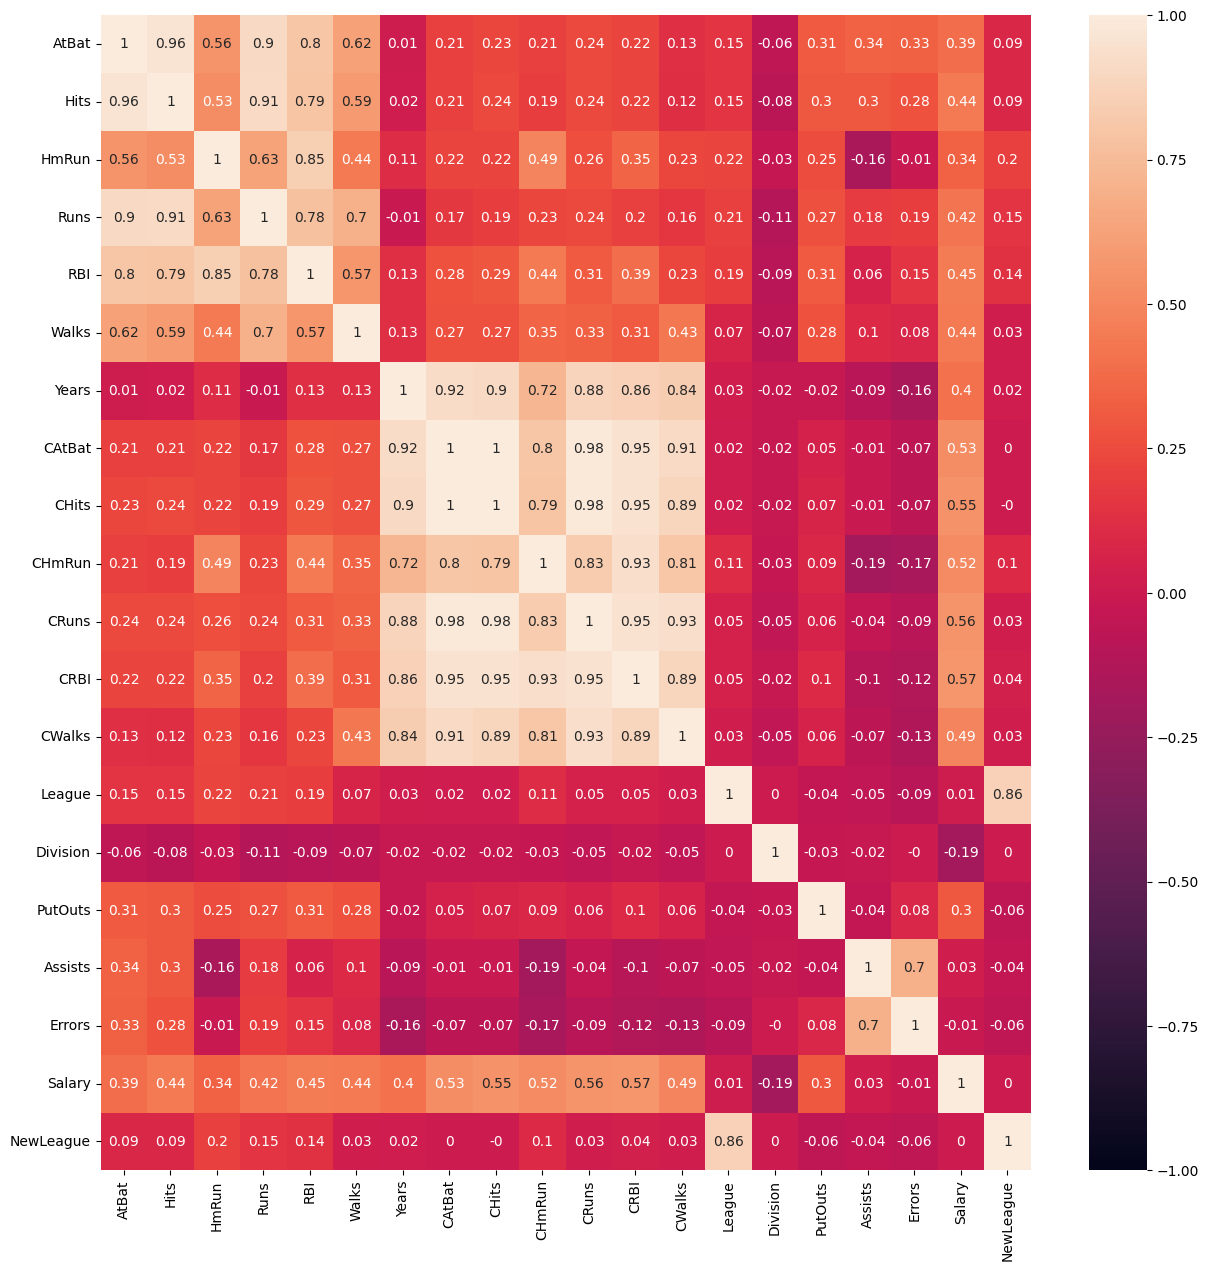

In [ ]:
#Let's take a look at a correlation plot
plt.figure(figsize=(15,15))
correlation_matrix = hits_clean.corr().round(2)
sns.heatmap(
    data=correlation_matrix,
    annot=True,
    vmin=-1,
    vmax=1,
);

### Correlation matrix plot - lower triangle


In [ ]:
np.set_printoptions(linewidth=200, suppress=True)

ones = np.ones_like(
    correlation_matrix,
    dtype=bool,
)
ones

array([[ True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True,  True, 

In [ ]:
#Create a mask
mask = np.tril(ones, k=-1)
mask

array([[False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False],
       [ True, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False],
       [ True,  True, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False],
       [ True,  True,  True, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False],
       [ True,  True,  True,  True, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False],
       [ True,  True,  True,  True,  True, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False],
       [ True,  True,  True,  True,  True,  True, False, False, False, False, False, False, False, False, 

In [ ]:
lower_triangle_corr = correlation_matrix.where(mask)
lower_triangle_corr

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
AtBat,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Hits,0.96,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HmRun,0.56,0.53,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Runs,0.90,0.91,0.63,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
RBI,0.80,0.79,0.85,0.78,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Walks,0.62,0.59,0.44,0.70,0.57,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Years,0.01,0.02,0.11,-0.01,0.13,0.13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CAtBat,0.21,0.21,0.22,0.17,0.28,0.27,0.92,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CHits,0.23,0.24,0.22,0.19,0.29,0.27,0.90,1.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CHmRun,0.21,0.19,0.49,0.23,0.44,0.35,0.72,0.80,0.79,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


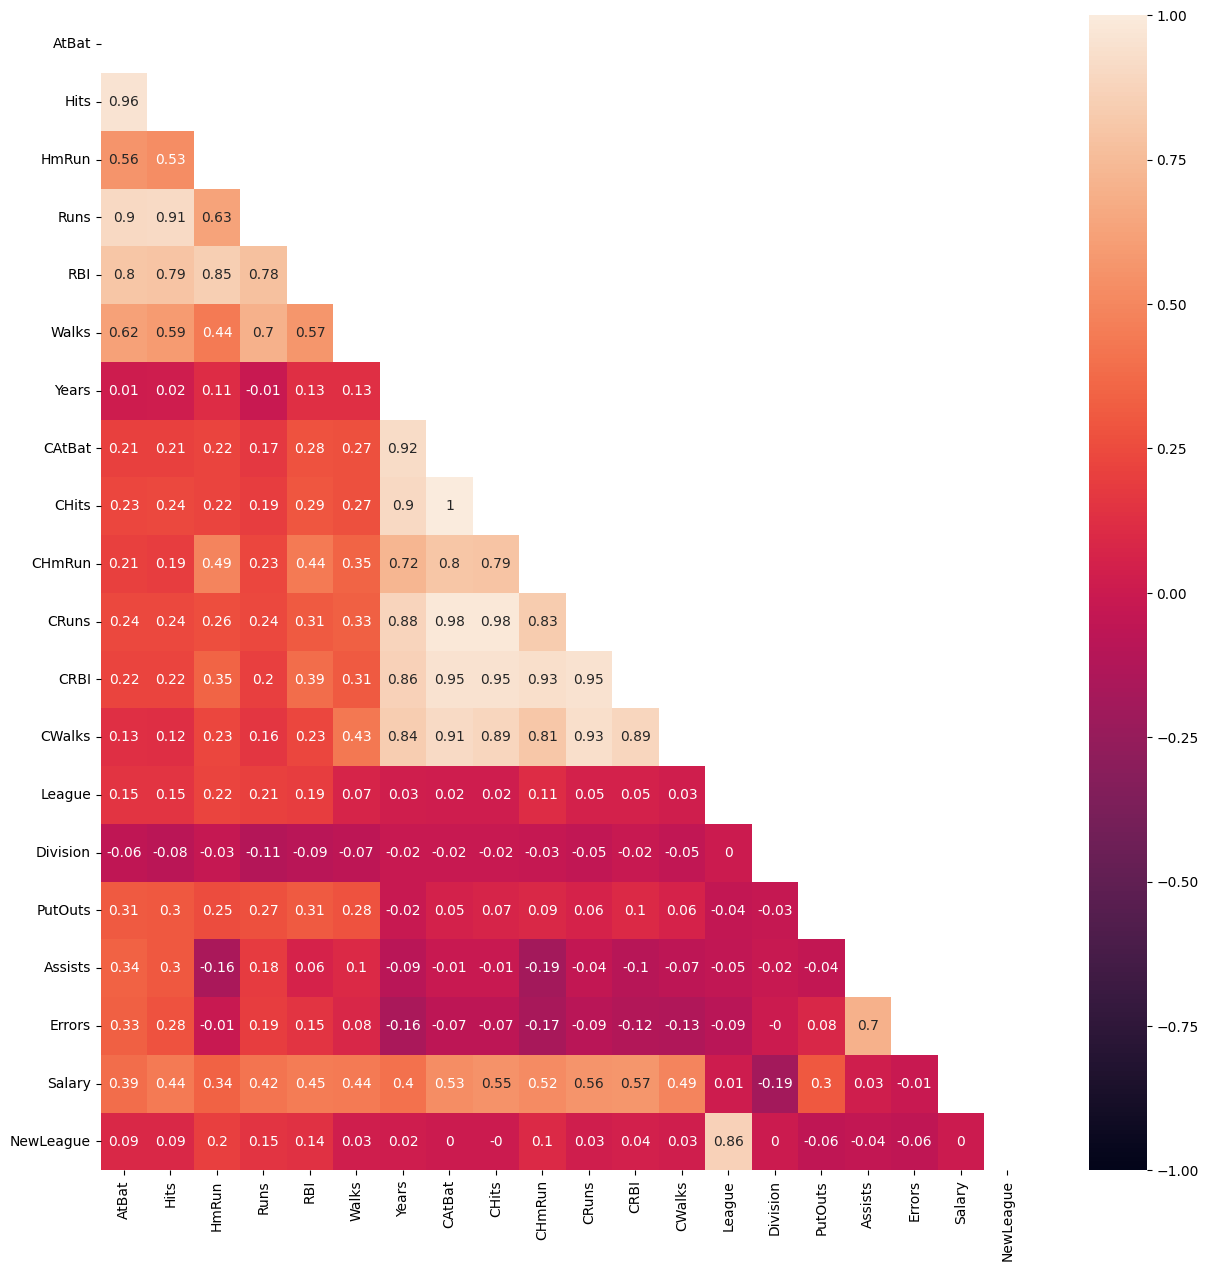

In [ ]:
plt.figure(figsize=(15,15))
sns.heatmap(
    data=lower_triangle_corr,
    annot=True,
    vmin=-1,
    vmax=1,
);

Create a list of the most highly correlated.

In [ ]:
lt_df = (
  lower_triangle_corr
  .unstack()
  .to_frame()
  .rename( columns={0:"A"} )
  .query( "A > 0.90")
  .sort_values( by = "A", ascending=False )
  .reset_index()
)
lt_df

,level_0,level_1,A
0,CAtBat,CHits,1.00
1,CAtBat,CRuns,0.98
2,CHits,CRuns,0.98
3,AtBat,Hits,0.96
4,CRuns,CRBI,0.95
5,CHits,CRBI,0.95
6,CAtBat,CRBI,0.95
7,CHmRun,CRBI,0.93
8,CRuns,CWalks,0.93
9,Years,CAtBat,0.92


In [ ]:
#Get list of highly correlated features
list(enumerate(set(lt_df.iloc[:,:2].stack().sort_values().to_list())))

[(0, 'CAtBat'),
 (1, 'CHits'),
 (2, 'Hits'),
 (3, 'CRBI'),
 (4, 'CRuns'),
 (5, 'Runs'),
 (6, 'AtBat'),
 (7, 'CHmRun'),
 (8, 'Years'),
 (9, 'CWalks')]

Several of the predictors are highly correlated and cluster into two groups:
- Years, CAtBat, CHits, CHmRun, CRuns, CRBI, CWalks
- AtBat, Hits, Runs

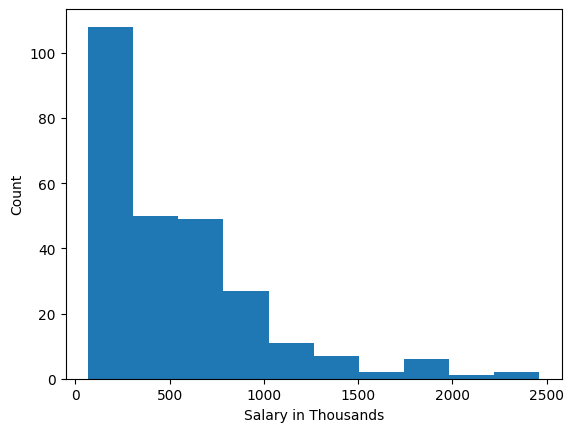

In [ ]:
#Let's look at the distribution of salaries
plt.hist(hits_clean['Salary'])
plt.xlabel('Salary in Thousands')
plt.ylabel("Count")
plt.savefig('test.png')

Within each group, the features that are most highly correlated with salary are CRBI and Hits.

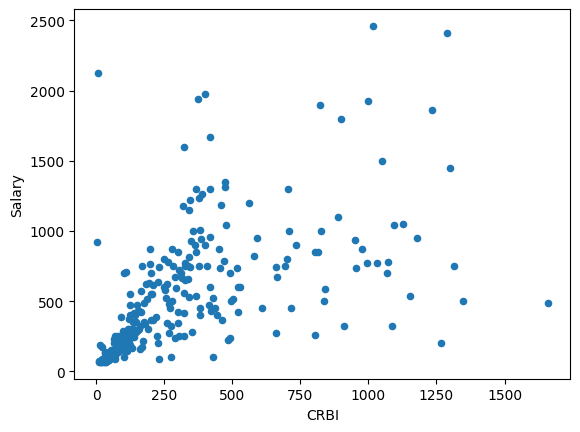

In [ ]:
#Let's look at a scatterplot of CRBI and Salary
hits_clean.plot('CRBI', 'Salary', kind = 'scatter') ;

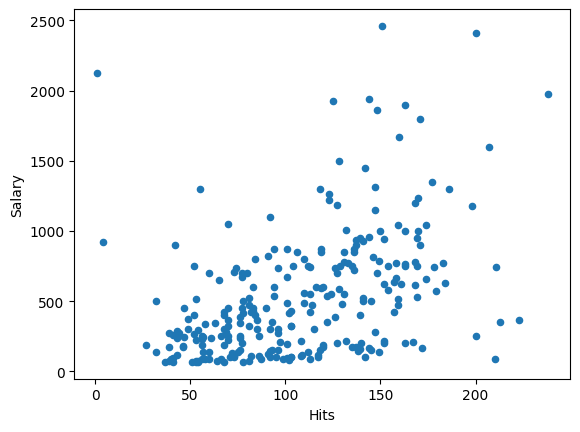

In [ ]:
#Let's look at a scatterplot of hits and salary
hits_clean.plot('Hits', 'Salary', kind = 'scatter');

## Linear Regression
We will first fit a multiple linear regression model. We are going to drop some of the highly correlated predictors and keep the two most highly correlated with Salary: Hits and CRBI.

In [ ]:
#First we will break up our data into training and testing sets
X = hits_clean.drop(['CRuns', 'CHmRun', 'CHits', 'CAtBat', 'CWalks', 'Runs', 'AtBat', 'Years', 'Salary'], axis = 1).copy()
y = hits_clean['Salary']

#Normalize the features
scaler = StandardScaler()
scaler.fit_transform(X)

array([[-0.59567545, -0.5285512 , -0.52206292, ..., -0.52319133,  0.21335208, -1.07505242],
       [ 0.49225957,  0.72996619,  0.79405962, ..., -0.25386267,  0.81996395,  0.9301872 ],
       [ 0.73648988,  0.95878753,  1.02631654, ..., -0.74417894, -0.84821868, -1.07505242],
       ...,
       [ 0.40344855, -0.98619389, -0.32851549, ..., -0.03978092, -0.24160682,  0.9301872 ],
       [ 0.80309815, -0.29972986,  0.32954578, ...,  0.08452461,  0.51665801,  0.9301872 ],
       [ 1.38036979, -0.29972986, -0.289806  , ..., -0.79251998, -0.84821868,  0.9301872 ]])

In [ ]:
X.columns

Index(['Hits', 'HmRun', 'RBI', 'Walks', 'CRBI', 'League', 'Division',
       'PutOuts', 'Assists', 'Errors', 'NewLeague'],
      dtype='object')

In [ ]:
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size = 0.2, random_state=5)

In [ ]:
X.head()

,Hits,HmRun,RBI,Walks,CRBI,League,Division,PutOuts,Assists,Errors,NewLeague
1,81,7,38,39,414,0,1,632,43,10,0
2,130,18,72,76,266,1,1,880,82,14,1
3,141,20,78,37,838,0,0,200,11,3,0
4,87,10,42,30,46,0,0,805,40,4,0
5,169,4,51,35,336,1,1,282,421,25,1


In [ ]:
X_scaled.head()

,Hits,HmRun,RBI,Walks,CRBI,League,Division,PutOuts,Assists,Errors,NewLeague
0,-0.595675,-0.528551,-0.522063,-0.097527,0.258966,-1.058758,0.981166,1.221499,-0.523191,0.213352,-1.075052
1,0.492260,0.729966,0.794060,1.609373,-0.199590,0.944503,0.981166,2.109109,-0.253863,0.819964,0.930187
2,0.736490,0.958788,1.026317,-0.189792,1.572666,-1.058758,-1.019196,-0.324661,-0.744179,-0.848219,-1.075052
3,-0.462459,-0.185319,-0.367225,-0.512719,-0.881228,-1.058758,-1.019196,1.840678,-0.543909,-0.696566,-1.075052
4,1.358167,-0.871783,-0.018840,-0.282057,0.017294,0.944503,0.981166,-0.031177,2.087225,2.488147,0.930187


In [ ]:
#Fit a linear model using Sklearn
model = LinearRegression()
my_fit_lr = model.fit(X_train, y_train)

In [ ]:
#Create a data frame with the results from the linear regression models
model_results = pd.DataFrame()
model_results['Predictor'] = X_train.columns
model_results['Linear'] = my_fit_lr.coef_
model_results.sort_values(by=['Linear'],inplace=True, ascending=False)
model_results

,Predictor,Linear
4,CRBI,248.613188
0,Hits,163.209853
3,Walks,87.576231
7,PutOuts,77.040205
10,NewLeague,48.936424
1,HmRun,9.279079
9,Errors,-12.814546
8,Assists,-13.151887
6,Division,-35.581253
5,League,-66.764783


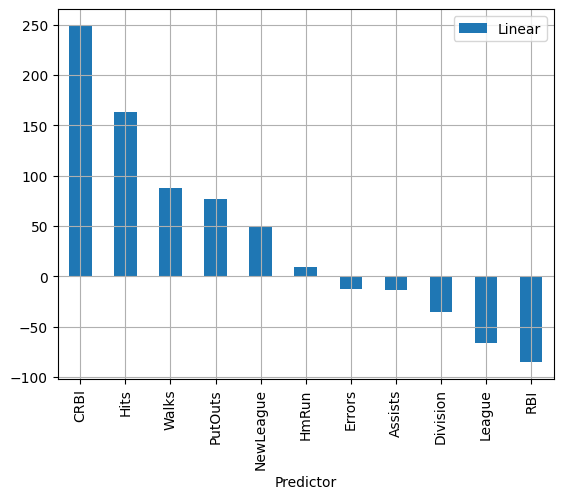

In [ ]:
#We can even plot the coefficients if we want to!
model_results.plot(x = 'Predictor', y = 'Linear', kind = 'bar')
plt.grid()

In [ ]:
#Calculate CV RMSE
results = cross_val_score(
    model,
    X_scaled,
    y,
    scoring='neg_root_mean_squared_error',
    cv = 10
    )
rmse = abs(results.mean())
print(f"CV RMSE: {rmse}")

CV RMSE: 332.0914203470625


This is showing that we have a RMSE of about $332k.

**NOTE**: We did not do any residual analysis in this example, although it is an important part of checking the assumptions of a linear regression model. Please refer back to the linear regression lecture for an example of how to check residuals.

## Regularization - Ridge Regression

In [ ]:
#Train the model
my_fit_rr = Ridge(alpha = 1) # Arbitrarily choosing alpha = 1
my_fit_rr.fit(X_train, y_train);

In [ ]:
#Calculate RMSE
y_pred = my_fit_rr.predict(X_test)
rmse = np.sqrt(np.mean(np.square(y_test - y_pred)))
print(f"RMSE: {rmse}")

RMSE: 456.67315431372975


Let's try looking at different values of $\alpha$.

In [ ]:
#Specify values of alpha we want to try
alpha = [1e-15, 1e-10, 1e-8, 1e-4, 1e-3, 1e-2, 1e-1, 1, 2, 3, 4, 5, 10, 20, 30, 50]

#Create empty list to hold results
results_alpha = []

for a in alpha:
  #Train the model
  my_fit_rr = Ridge(alpha = a) #Looping through alpha
  my_fit_rr.fit(X_train, y_train)

  #Calculate CV RMSE
  results = cross_val_score(
      my_fit_rr,
      X_scaled,
      y,
      scoring='neg_root_mean_squared_error',
      cv = 10
      )
  rmse = abs(results.mean())
  results_alpha.append(rmse)

results_df = pd.DataFrame({'Alpha': alpha, 'RMSE': results_alpha})
print(results_df.sort_values(by=['RMSE']))

           Alpha        RMSE
14  3.000000e+01  329.514835
13  2.000000e+01  329.690766
15  5.000000e+01  329.966530
12  1.000000e+01  330.360827
11  5.000000e+00  331.018304
10  4.000000e+00  331.190918
9   3.000000e+00  331.381486
8   2.000000e+00  331.592692
7   1.000000e+00  331.827903
6   1.000000e-01  332.063648
5   1.000000e-02  332.088628
4   1.000000e-03  332.091141
3   1.000000e-04  332.091392
2   1.000000e-08  332.091420
1   1.000000e-10  332.091420
0   1.000000e-15  332.091420


In [ ]:
results_df.sort_values( by = ["Alpha"])

,Alpha,RMSE
0,1.000000e-15,332.091420
1,1.000000e-10,332.091420
2,1.000000e-08,332.091420
3,1.000000e-04,332.091392
4,1.000000e-03,332.091141
5,1.000000e-02,332.088628
6,1.000000e-01,332.063648
7,1.000000e+00,331.827903
8,2.000000e+00,331.592692
9,3.000000e+00,331.381486


It looks like 20 gives us the smallest RMSE.

In [ ]:
#Retrain the model w/ alpha = 20
my_fit_rr = Ridge(alpha = 30)
my_fit_rr.fit(X_train, y_train)

#Calculate CV RMSE
results = cross_val_score(my_fit_rr, X_scaled, y, scoring='neg_root_mean_squared_error', cv = 10)
rmse = abs(results.mean())
print(f"CV RMSE: {rmse}")

CV RMSE: 329.51483481250546


In [ ]:
#Add ridge regression results to data frame we created earlier
model_results['Ridge'] = my_fit_rr.coef_

In [ ]:
model_results

,Predictor,Linear,Ridge
4,CRBI,248.613188,104.708478
0,Hits,163.209853,-9.725810
3,Walks,87.576231,-2.951077
7,PutOuts,77.040205,82.883617
10,NewLeague,48.936424,205.418022
1,HmRun,9.279079,-36.367011
9,Errors,-12.814546,-31.278876
8,Assists,-13.151887,72.691640
6,Division,-35.581253,-1.693883
5,League,-66.764783,-17.112980


## Regularization - Lasso Regression


In [ ]:
#Specify values of alpha we want to try
alpha = [1e-15, 1e-10, 1e-8, 1e-4, 1e-3, 1e-2, 1e-1, 1, 2, 3, 4, 5, 10, 20, 30, 50]

#Create empty list to hold results
results_alpha = []

for i in alpha:
  #Train the model
  my_fit_lasso = Lasso(alpha = i, tol = .01, max_iter=100_000) # Looping through alpha
  my_fit_lasso.fit(X_train, y_train)

  #Calculate CV RMSE
  results = cross_val_score(
      my_fit_lasso,
      X_scaled,
      y,
      scoring='neg_root_mean_squared_error',
      cv = 10
  )
  rmse = abs(results.mean())
  results_alpha.append(rmse)

results_df = pd.DataFrame({'Alpha': alpha, 'RMSE': results_alpha})
print(results_df.sort_values(by=['RMSE']))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.012e+06, tolerance: 4.305e+05
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.234e+07, tolerance: 5.077e+05
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.213e+07, tolerance: 4.958e

           Alpha        RMSE
13  2.000000e+01  327.103390
12  1.000000e+01  327.582006
11  5.000000e+00  328.716548
14  3.000000e+01  328.951869
10  4.000000e+00  329.149721
9   3.000000e+00  329.800572
8   2.000000e+00  330.447732
7   1.000000e+00  331.151462
6   1.000000e-01  331.991497
5   1.000000e-02  332.081601
4   1.000000e-03  332.090431
3   1.000000e-04  332.091322
2   1.000000e-08  332.091420
1   1.000000e-10  332.091420
0   1.000000e-15  332.091420
15  5.000000e+01  336.114500


In [ ]:
results_df

,Alpha,RMSE
0,1.000000e-15,332.091420
1,1.000000e-10,332.091420
2,1.000000e-08,332.091420
3,1.000000e-04,332.091322
4,1.000000e-03,332.090431
5,1.000000e-02,332.081601
6,1.000000e-01,331.991497
7,1.000000e+00,331.151462
8,2.000000e+00,330.447732
9,3.000000e+00,329.800572


In [ ]:
#Train the model
my_fit_lasso = Lasso(alpha = 20, tol = .01, max_iter=1_000_000)
my_fit_lasso.fit(X_train, y_train)

#Calculate CV RMSE
results = cross_val_score(my_fit_lasso, X_scaled, y, scoring='neg_root_mean_squared_error', cv = 10)
rmse = abs(results.mean())
print(f"CV RMSE: {rmse}")

CV RMSE: 327.10338991503653


In [ ]:
#Add Lasso results to the data frame we created before
model_results['Lasso'] = my_fit_lasso.coef_

## Summary

In [ ]:
model_results

,Predictor,Linear,Ridge,Lasso
4,CRBI,248.613188,104.708478,87.939712
0,Hits,163.209853,-9.725810,-0.000000
3,Walks,87.576231,-2.951077,-0.000000
7,PutOuts,77.040205,82.883617,72.985974
10,NewLeague,48.936424,205.418022,220.959403
1,HmRun,9.279079,-36.367011,-3.025971
9,Errors,-12.814546,-31.278876,-17.467624
8,Assists,-13.151887,72.691640,65.853826
6,Division,-35.581253,-1.693883,-0.000000
5,League,-66.764783,-17.112980,-0.000000


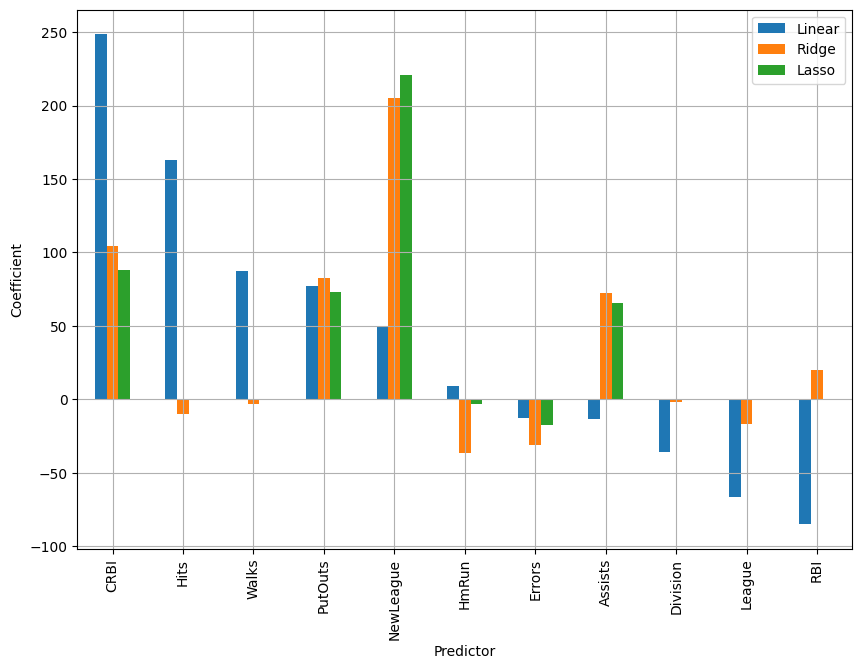

In [ ]:
#Plot results
fig, ax = plt.subplots(1,1, figsize = (10,7))
model_results.plot(x = 'Predictor', kind = 'bar', ax = ax)
ax.set_ylabel('Coefficient')
plt.grid()

After performing regularization, we were able to reduce our RMSE from
\$332k with linear regression to
\$329k with Ridge regression to
\$327k with Lasso regression.

For all models, CRBI seems to be one of the more important predictors of salary.

In [ ]:
model_results

,Predictor,Linear,Ridge,Lasso
4,CRBI,248.613188,104.708478,87.939712
0,Hits,163.209853,-9.725810,-0.000000
3,Walks,87.576231,-2.951077,-0.000000
7,PutOuts,77.040205,82.883617,72.985974
10,NewLeague,48.936424,205.418022,220.959403
1,HmRun,9.279079,-36.367011,-3.025971
9,Errors,-12.814546,-31.278876,-17.467624
8,Assists,-13.151887,72.691640,65.853826
6,Division,-35.581253,-1.693883,-0.000000
5,League,-66.764783,-17.112980,-0.000000
